In [3]:
import numpy as np
import matplotlib.pyplot as plt                           #importing libraries
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve

In [4]:
df=pd.read_csv("C:/Users/ADMIN/Downloads/sacco_loan_dataset.csv")               #loading the dataset
df.head()

,Age,Monthly_Income,Employment_Type,Loan_Amount,Loan_Purpose,Credit_History,Repayment_Defaults,Membership_Years,Guarantors,Loan_Status
0,58,19592.0,self-employed,133393.0,farming,poor,0,10.3,no,0
1,19,17280.0,informal,269951.0,housing,good,5,NaN,yes,1
2,55,41463.0,informal,NaN,business expansion,fair,1,NaN,yes,0
3,42,NaN,self-employed,NaN,school fees,poor,3,NaN,yes,1
4,58,NaN,informal,374398.0,school fees,poor,1,11.7,yes,0


Loan_Status
1    214
0    186
Name: count, dtype: int64


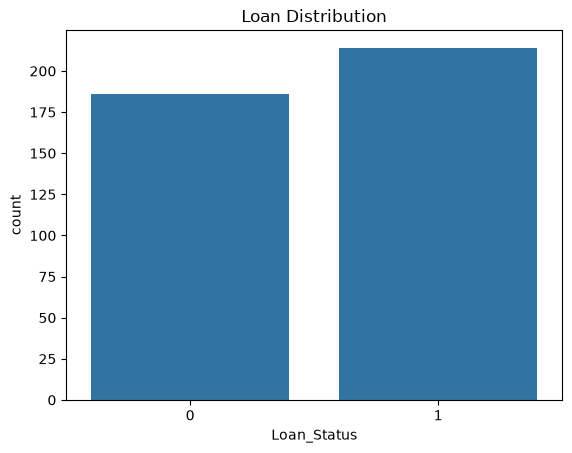

Categorical: ['Employment_Type', 'Loan_Purpose', 'Credit_History', 'Guarantors']
Numerical: ['Age', 'Monthly_Income', 'Loan_Amount', 'Repayment_Defaults', 'Membership_Years', 'Loan_Status']


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20536\1512936378.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features=df.select_dtypes(include=['object']).columns.tolist()


In [5]:
print(df['Loan_Status'].value_counts())                     #Exploratory Data Analysis
sns.countplot(x='Loan_Status',data=df)
plt.title('Loan Distribution')
plt.show()

categorical_features=df.select_dtypes(include=['object']).columns.tolist()
numerical_features=df.select_dtypes(include=['int64','float64']).columns.tolist()

print('Categorical:',categorical_features)
print('Numerical:',numerical_features)

In [6]:
df['Loan_Status'].value_counts(normalize=True)

Loan_Status
1    0.535
0    0.465
Name: proportion, dtype: float64

In [7]:
df=pd.get_dummies(df,columns=["Employment_Type"],drop_first=False,dtype=int)

In [8]:
df.filter(like='Employment_Type').columns

Index(['Employment_Type_formal', 'Employment_Type_informal',
       'Employment_Type_self-employed', 'Employment_Type_unemployed'],
      dtype='str')

In [9]:
df.Loan_Purpose.unique()

<StringArray>
['farming', 'housing', 'business expansion', 'school fees', 'medical']
Length: 5, dtype: str

In [10]:
df=pd.get_dummies(df,columns=["Loan_Purpose"],drop_first=False,dtype=int)

In [11]:
df.filter(like='Loan_Purpose').columns

Index(['Loan_Purpose_business expansion', 'Loan_Purpose_farming',
       'Loan_Purpose_housing', 'Loan_Purpose_medical',
       'Loan_Purpose_school fees'],
      dtype='str')

In [12]:
df=pd.get_dummies(df,columns=["Credit_History"],drop_first=False,dtype=int)

In [13]:
df.filter(like='Credit_History').columns

Index(['Credit_History_fair', 'Credit_History_good', 'Credit_History_poor'], dtype='str')

In [14]:
df["Guarantors"]=pd.get_dummies(df["Guarantors"],drop_first=True,dtype=int)

In [15]:
df.head()

,Age,Monthly_Income,Loan_Amount,Repayment_Defaults,Membership_Years,Guarantors,Loan_Status,Employment_Type_formal,Employment_Type_informal,Employment_Type_self-employed,Employment_Type_unemployed,Loan_Purpose_business expansion,Loan_Purpose_farming,Loan_Purpose_housing,Loan_Purpose_medical,Loan_Purpose_school fees,Credit_History_fair,Credit_History_good,Credit_History_poor
0,58,19592.0,133393.0,0,10.3,0,0,0,0,1,0,0,1,0,0,0,0,0,1
1,19,17280.0,269951.0,5,NaN,1,1,0,1,0,0,0,0,1,0,0,0,1,0
2,55,41463.0,NaN,1,NaN,1,0,0,1,0,0,1,0,0,0,0,1,0,0
3,42,NaN,NaN,3,NaN,1,1,0,0,1,0,0,0,0,0,1,0,0,1
4,58,NaN,374398.0,1,11.7,1,0,0,1,0,0,0,0,0,0,1,0,0,1


In [16]:
df.isnull().sum()

Age                                  0
Monthly_Income                     194
Loan_Amount                        215
Repayment_Defaults                   0
Membership_Years                   220
Guarantors                           0
Loan_Status                          0
Employment_Type_formal               0
Employment_Type_informal             0
Employment_Type_self-employed        0
Employment_Type_unemployed           0
Loan_Purpose_business expansion      0
Loan_Purpose_farming                 0
Loan_Purpose_housing                 0
Loan_Purpose_medical                 0
Loan_Purpose_school fees             0
Credit_History_fair                  0
Credit_History_good                  0
Credit_History_poor                  0
dtype: int64

In [17]:
df['Monthly_Income']=df['Monthly_Income'].fillna(df['Monthly_Income'].median())
df['Loan_Amount']=df['Loan_Amount'].fillna(df['Loan_Amount'].median())
df['Membership_Years']=df['Membership_Years'].fillna(df['Membership_Years'].median())

In [18]:
df.isnull().sum()

Age                                0
Monthly_Income                     0
Loan_Amount                        0
Repayment_Defaults                 0
Membership_Years                   0
Guarantors                         0
Loan_Status                        0
Employment_Type_formal             0
Employment_Type_informal           0
Employment_Type_self-employed      0
Employment_Type_unemployed         0
Loan_Purpose_business expansion    0
Loan_Purpose_farming               0
Loan_Purpose_housing               0
Loan_Purpose_medical               0
Loan_Purpose_school fees           0
Credit_History_fair                0
Credit_History_good                0
Credit_History_poor                0
dtype: int64

In [19]:
scaler=StandardScaler()
features=['Age','Monthly_Income','Loan_Amount','Repayment_Defaults','Membership_Years']
df[features]=scaler.fit_transform(df[features])

In [20]:
x=df.drop(columns=["Loan_Status"])

In [21]:
y=df["Loan_Status"]

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)  #Train Test split

In [23]:
model=LogisticRegression(max_iter=1000,random_state=42)
model.fit(x_train,y_train)       #Logistic Regression Model Training

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [24]:
df.Loan_Status.unique()

array([0, 1])

In [25]:
x_test.shape

(80, 18)

In [26]:
y_test.shape

(80,)

In [27]:
x_train.shape

(320, 18)

In [28]:
y_train.shape

(320,)

In [29]:
#model evaluation
y_pred=model.predict(x_test)
y_proba=model.predict_proba(x_test)[:,1]

print('Accuracy:',accuracy_score(y_test,y_pred))
print('\nClassification Report:\n',classification_report(y_test,y_pred))


Accuracy: 0.55

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.41      0.45        37
           1       0.57      0.67      0.62        43

    accuracy                           0.55        80
   macro avg       0.54      0.54      0.54        80
weighted avg       0.54      0.55      0.54        80



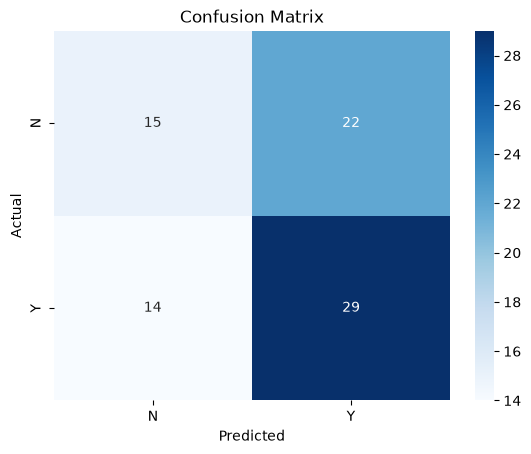

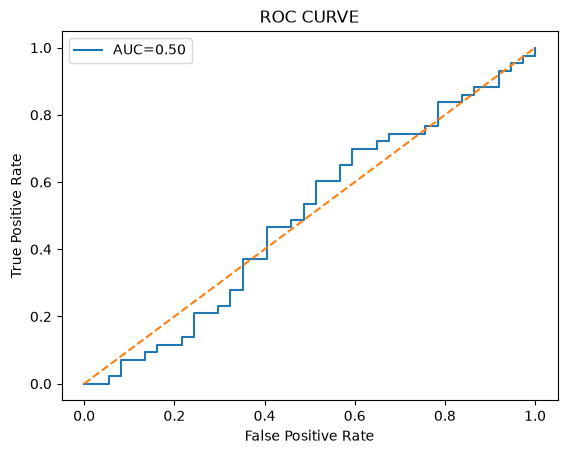

In [30]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap="Blues",xticklabels=['N','Y'],yticklabels=['N','Y'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

auc=roc_auc_score(y_test,y_proba)
fpr,tpr,thresholds=roc_curve(y_test,y_proba)
plt.plot(fpr,tpr,label=f'AUC={auc:.2f}')
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVE')
plt.legend()
plt.show()

 

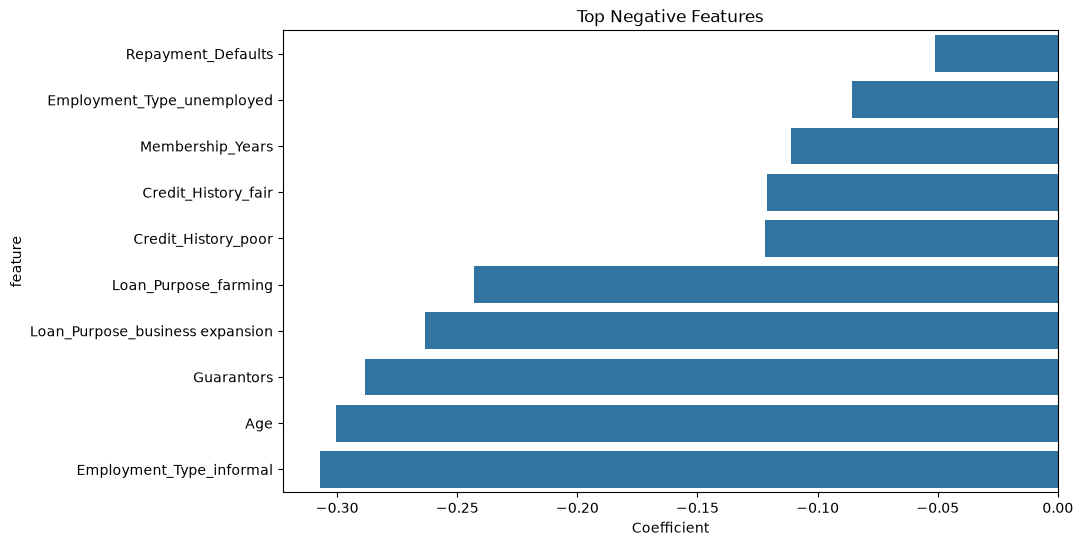

In [31]:
#Feature Importance (Coefficient Analysis)
coeffs=pd.DataFrame({
    'feature':x.columns,
    'Coefficient':model.coef_[0]}).sort_values(by='Coefficient',ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient',y='feature',data=coeffs.tail(10))
plt.title('Top Negative Features')
plt.show()


#Video Explanaton
[Watch the video here](https://youtu.be/aESHFwwtADk)